# Modelo Simple 2

Segundo modelo más simple, con dos capas convolucionales, con el mismo tamaño de filtro y kernel

### Impotacion y preprocesado de datos

In [ ]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.


### Modelo

In [ ]:
# Importar el modelo
import sys
sys.path.append('../')

import importlib
import models.simple_2_cnn
importlib.reload(models.simple_2_cnn) # recargamos el cache para tener la ultima versión del modelo 
from models.simple_3_cnn import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.01)

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,844 (93.14 KB)

 Trainable params: 23,844 (93.14 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - accuracy: 0.3784 - loss: 1.2910 - val_accuracy: 0.4609 - val_loss: 1.2114
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 371ms/step - accuracy: 0.4270 - loss: 1.2257 - val_accuracy: 0.4751 - val_loss: 1.2071
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 343ms/step - accuracy: 0.4579 - loss: 1.1830 - val_accuracy: 0.4822 - val_loss: 1.1579
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 349ms/step - accuracy: 0.4737 - loss: 1.1589 - val_accuracy: 0.5166 - val_loss: 1.1445
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 346ms/step - accuracy: 0.4887 - loss: 1.1498 - val_accuracy: 0.4917 - val_loss: 1.1792
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 362ms/step - accuracy: 0.4781 - loss: 1.1484 - val_accuracy: 0.4834 - val_loss: 1.2855
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 366ms/step - accuracy: 0.4792 - loss: 1.1532 - val_accuracy: 0.4810 - val_loss: 1.1731
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 364ms/step - accuracy: 0.4955 - loss: 1.1315 - 

### Resultados

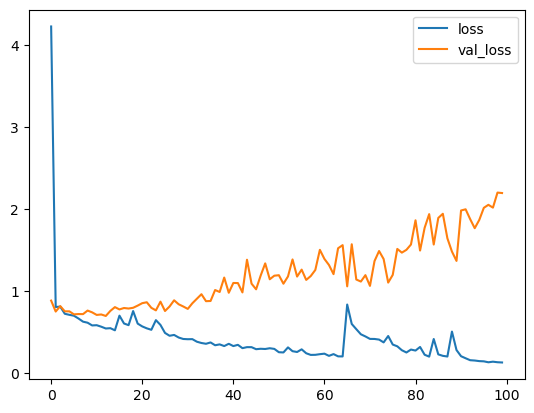

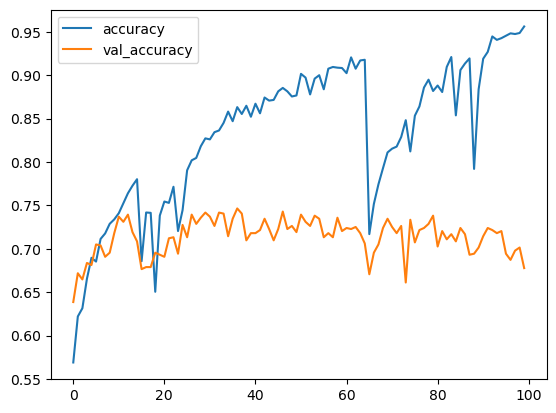

In [ ]:
import matplotlib.pyplot as plt
# Visualizacion evolucion loss durante el entrenamiento
plt.plot(hist.history['loss'],label="loss")
plt.plot(hist.history['val_loss'],label="val_loss")
plt.legend()
plt.show()

# Visualizacion de accuracy durante el entrenamiento
plt.plot(hist.history["accuracy"], label= "accuracy")
plt.plot(hist.history["val_accuracy"], label ="val_accuracy")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)
df.round(3)


80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


,Train,Val,Test
Accuracy,0.946,0.678,0.680
F1,0.946,0.681,0.684


In [ ]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

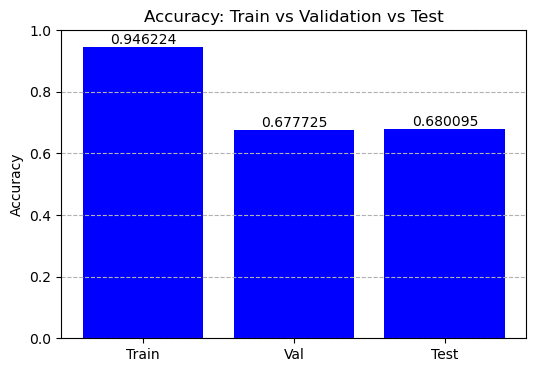

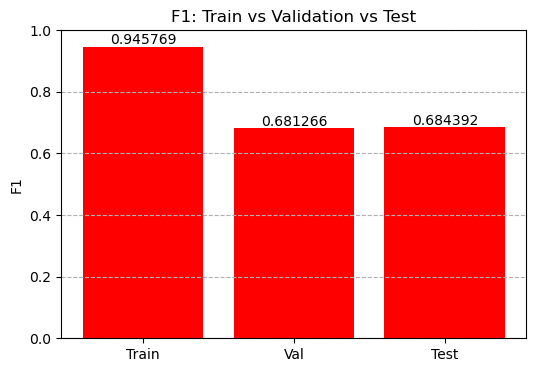

In [ ]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


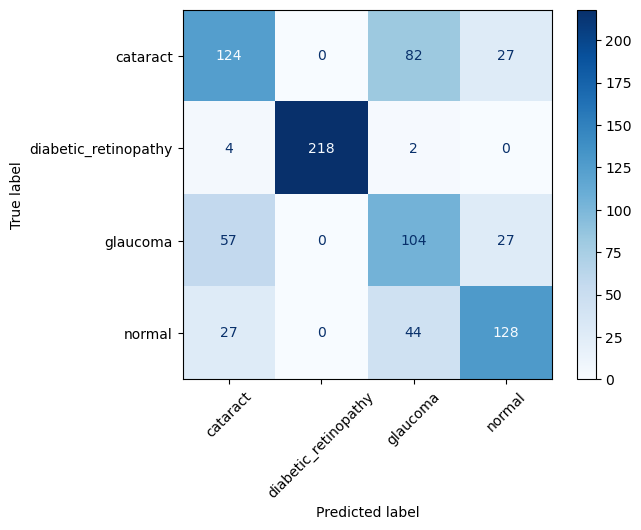

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.965,0.931,0.532,0.535,0.532,0.557
diabetic_retinopathy,1.000,1.000,0.978,0.985,0.973,0.986
glaucoma,0.974,0.942,0.518,0.483,0.553,0.495
normal,0.850,0.910,0.637,0.673,0.643,0.672


Modelo Conv 16 -> Conv 32 --> Falten:
            Train   Val  Test

Accuracy   0.946  0.678  0.68

F1         0.946  0.681  0.684

Modelo Conv 16 -> Conv 32 --> Conv 64 --> GlobalAverage:
            Train   Val  Test

Accuracy   

F1         